In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('data-security-incidents-trends-q1-2019-to-q4-2024.xlsx')

In [3]:
# 1. First 5 rows
print("1. First 5 rows:")
print(df.head())

# 2. Last 5 rows
print("\n2. Last 5 rows:")
print(df.tail())

# 3. Shape of the dataset
print("\n3. Shape of the dataset:")
print(df.shape)

# 4. Column names
print("\n4. Column names:")
print(df.columns.tolist())

# 5. Data types and non-null counts
print("\n5. Info summary:")
print(df.info())

1. First 5 rows:
  BI Reference  Year Quarter                   Data Subject Type  \
0          BI1  2019   Qtr 1  Customers or prospective customers   
1          BI1  2019   Qtr 1  Customers or prospective customers   
2          BI1  2019   Qtr 1  Customers or prospective customers   
3         BI10  2019   Qtr 1                           Employees   
4        BI100  2019   Qtr 1  Customers or prospective customers   

                     Data Type     Decision Taken Incident Category  \
0   Basic personal identifiers  No Further Action         Non Cyber   
1  Economic and financial data  No Further Action         Non Cyber   
2          Identification data  No Further Action         Non Cyber   
3          Identification data  No Further Action         Non Cyber   
4   Basic personal identifiers  No Further Action         Non Cyber   

                                   Incident Type No. Data Subjects Affected  \
0  Loss/theft of device containing personal data                  10

In [5]:
# 6. Check for missing values
print("\n6. Missing values per column:")
print(df.isnull().sum())

# 7. Number of duplicated rows
print("\n7. Number of duplicated rows:")
print(df.duplicated().sum())

# 8. Descriptive statistics (numerical columns)
print("\n8. Descriptive statistics:")
print(df.describe())

# 9. Unique values per column
print("\n9. Unique values per column:")
print(df.nunique())

# 10. Correlation matrix (numerical only)
print("\n10. Correlation matrix:")
print(df.corr(numeric_only=True))



6. Missing values per column:
BI Reference                  0
Year                          0
Quarter                       0
Data Subject Type             0
Data Type                     0
Decision Taken                0
Incident Category             0
Incident Type                 0
No. Data Subjects Affected    0
Sector                        0
Time Taken to Report          0
dtype: int64

7. Number of duplicated rows:
0

8. Descriptive statistics:
                Year
count  169166.000000
mean     2021.578497
std         1.779221
min      2019.000000
25%      2020.000000
50%      2022.000000
75%      2023.000000
max      2024.000000

9. Unique values per column:
BI Reference                  33387
Year                              6
Quarter                           4
Data Subject Type                 9
Data Type                        16
Decision Taken                    5
Incident Category                 2
Incident Type                    22
No. Data Subjects Affected        7


In [22]:
def convert_range_to_midpoint(range_str):
    if pd.isna(range_str):
        return np.nan
    range_str = str(range_str).strip().lower()
    if 'to' in range_str:
        low_str, high_str = map(str.strip, range_str.split('to'))
        low = float(low_str.replace('k', '000').replace(',', ''))
        high = float(high_str.replace('k', '000').replace(',', ''))
        return (low + high) / 2
    elif '+' in range_str or 'and above' in range_str:
        # e.g., '100k+', '100k and above'
        return float(range_str.replace('+','').replace('and above','').replace('k','000').replace(',','').strip())
    elif range_str == 'unknown':
        return np.nan
    else:
        return float(range_str.replace('k', '000').replace(',', '').strip())

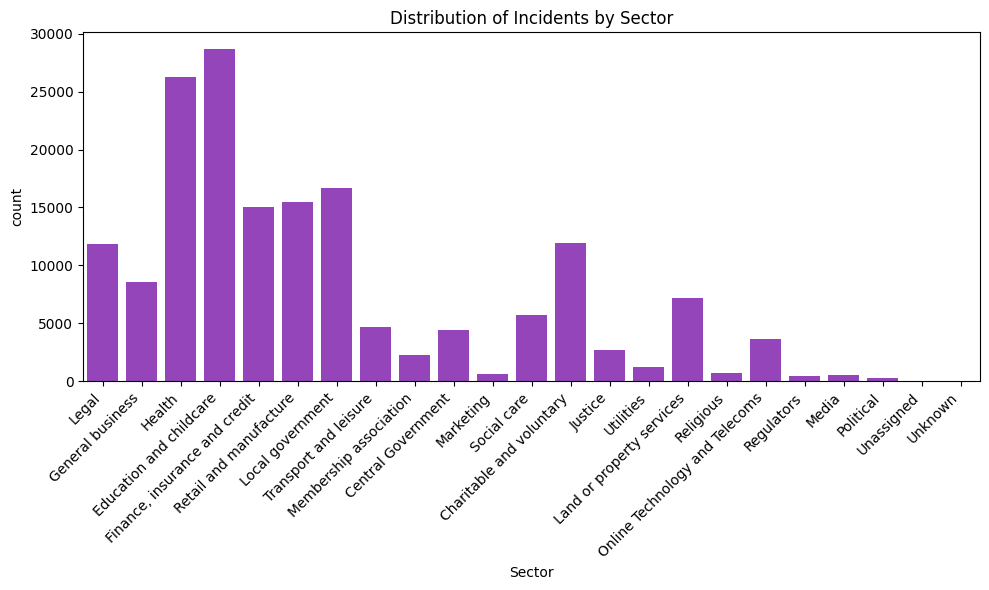

In [17]:
# 1. Bar Plot - Sector Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Sector', color='#9932CC')
plt.title('Distribution of Incidents by Sector')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_27128\381816211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=decision_counts.index, x=decision_counts.values,
C:\Users\HP\AppData\Local\Temp\ipykernel_27128\381816211.py:4: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(y=decision_counts.index, x=decision_counts.values,


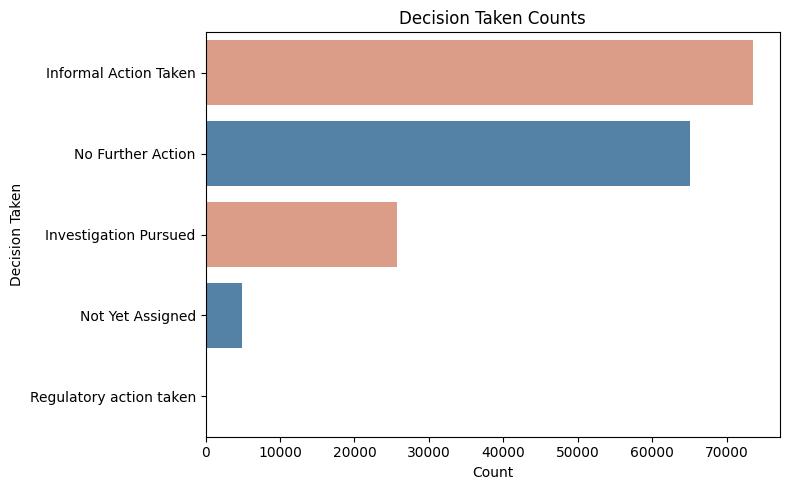

In [19]:
# 2. Horizontal Bar Chart - Decision Taken
decision_counts = df['Decision Taken'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(y=decision_counts.index, x=decision_counts.values, 
            palette=['#E9967A', '#4682B4'], orient='h')
plt.title('Decision Taken Counts')
plt.xlabel('Count')
plt.ylabel('Decision Taken')
plt.grid(False)
plt.tight_layout()
plt.show()


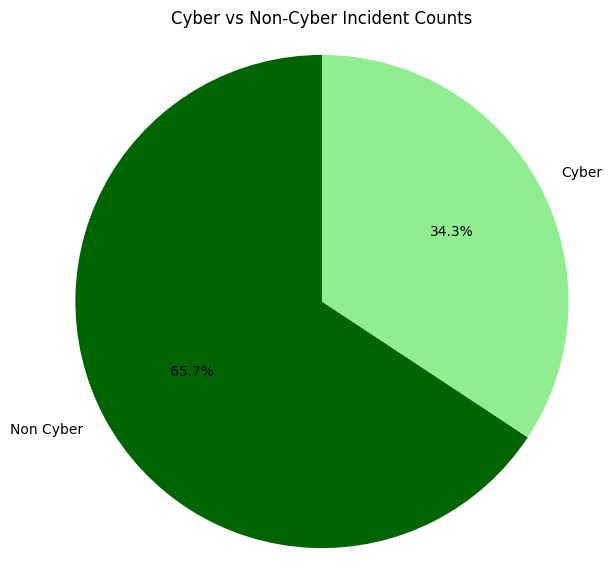

In [27]:
# 4. Pie Chart - Cyber vs Non-Cyber
cyber_counts = df['Incident Category'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(cyber_counts, labels=cyber_counts.index,
        colors=['#006400', '#90EE90'], autopct='%1.1f%%', startangle=90)
plt.title('Cyber vs Non-Cyber Incident Counts')
plt.axis('equal')  # keeps circle aspect
plt.show()

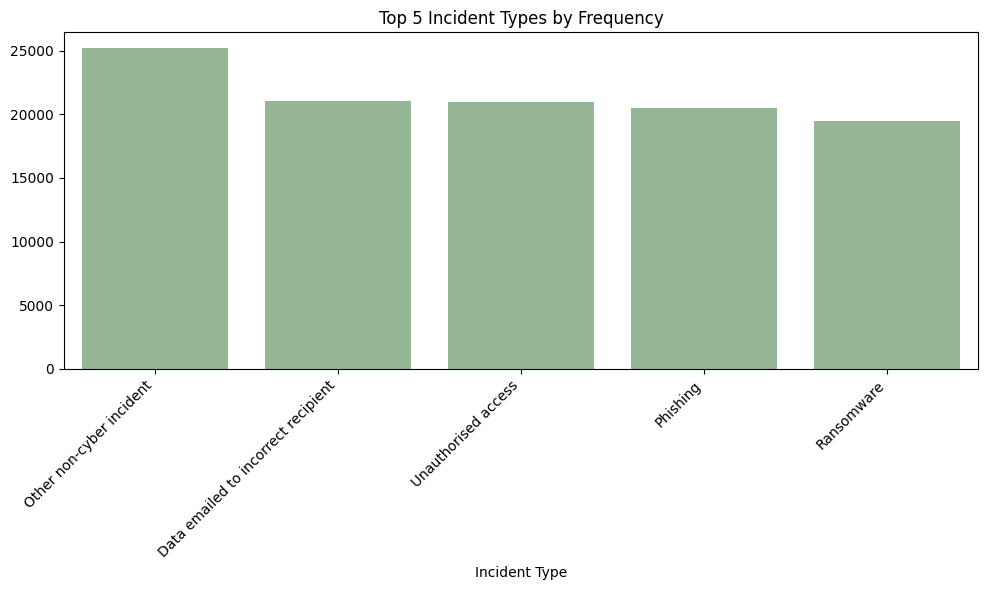

In [29]:
# 6. Bar Plot - Top 5 Incident Types
top_incidents = df['Incident Type'].value_counts().head(5)
plt.figure(figsize=(10,6))
sns.barplot(x=top_incidents.index, y=top_incidents.values, color='#8FBC8F')
plt.title('Top 5 Incident Types by Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()
plt.show()

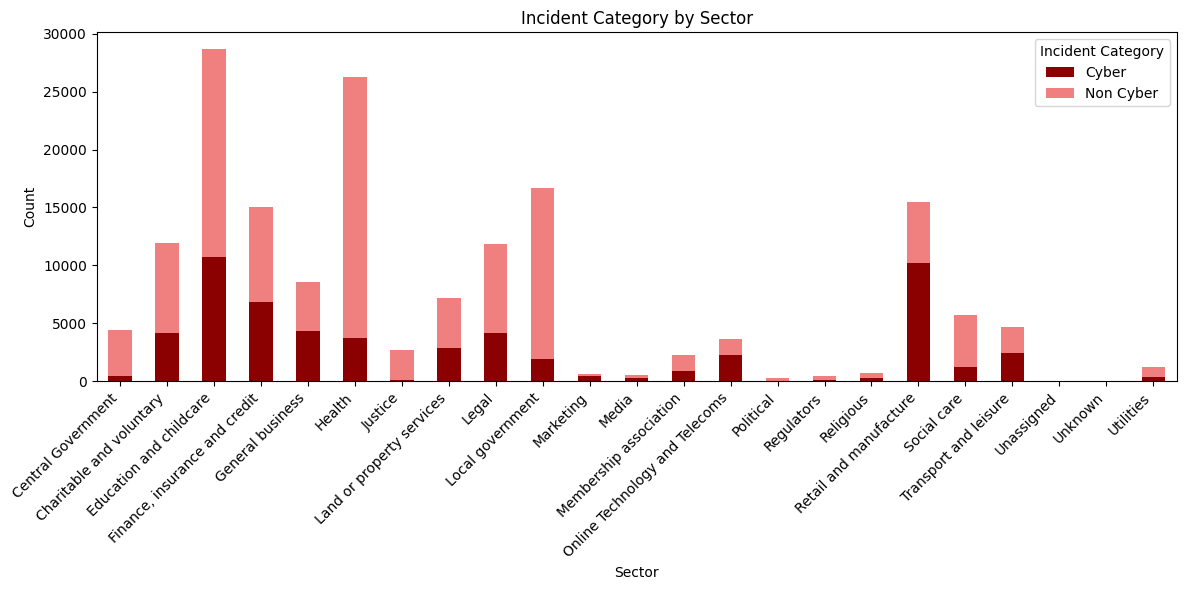

In [30]:
# 7. Stacked Bar - Incident Category by Sector
sector_incident = pd.crosstab(df['Sector'], df['Incident Category'])
sector_incident.plot(kind='bar', stacked=True, 
                     color=['#8B0000', '#F08080'], figsize=(12,6))
plt.title('Incident Category by Sector')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()
plt.show()


In [36]:
def convert_range_to_midpoint(range_str):
    if pd.isna(range_str):
        return np.nan
    range_str = str(range_str).strip().lower()
    if 'to' in range_str:
        low_str, high_str = map(str.strip, range_str.split('to'))
        low = float(low_str.replace('k', '000').replace(',', ''))
        high = float(high_str.replace('k', '000').replace(',', ''))
        return (low + high) / 2
    elif '+' in range_str or 'and above' in range_str:
        return float(range_str.replace('+','').replace('and above','').replace('k','000').replace(',','').strip())
    elif range_str == 'unknown':
        return np.nan
    else:
        return float(range_str.replace('k', '000').replace(',', '').strip())

df['No. Data Subjects Affected Num'] = df['No. Data Subjects Affected'].apply(convert_range_to_midpoint)

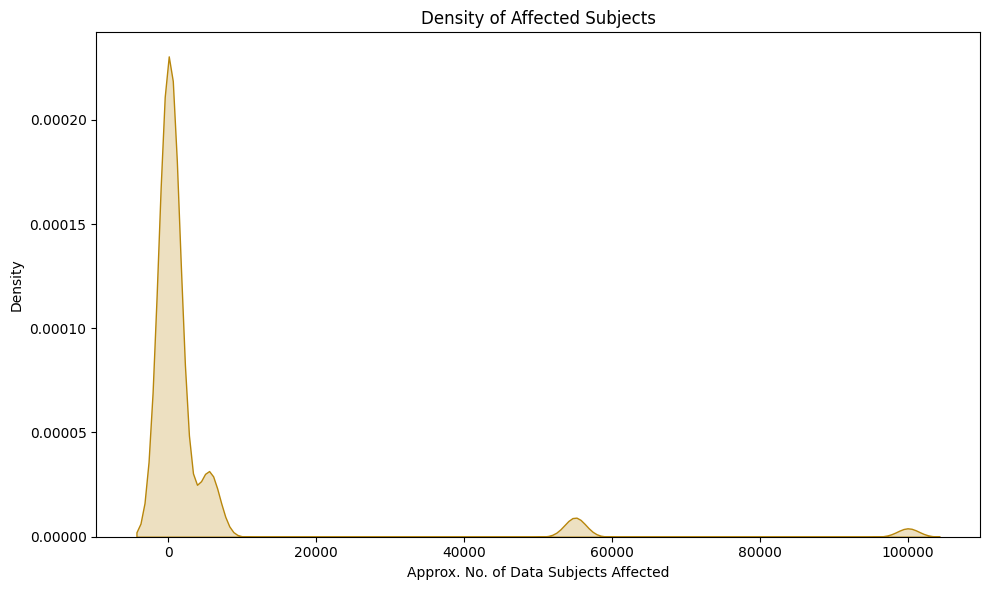

In [37]:
plt.figure(figsize=(10,6))
sns.kdeplot(x=df['No. Data Subjects Affected Num'], 
            color='#B8860B', fill=True)
plt.title('Density of Affected Subjects')
plt.xlabel('Approx. No. of Data Subjects Affected')
plt.grid(False)
plt.tight_layout()
plt.show()

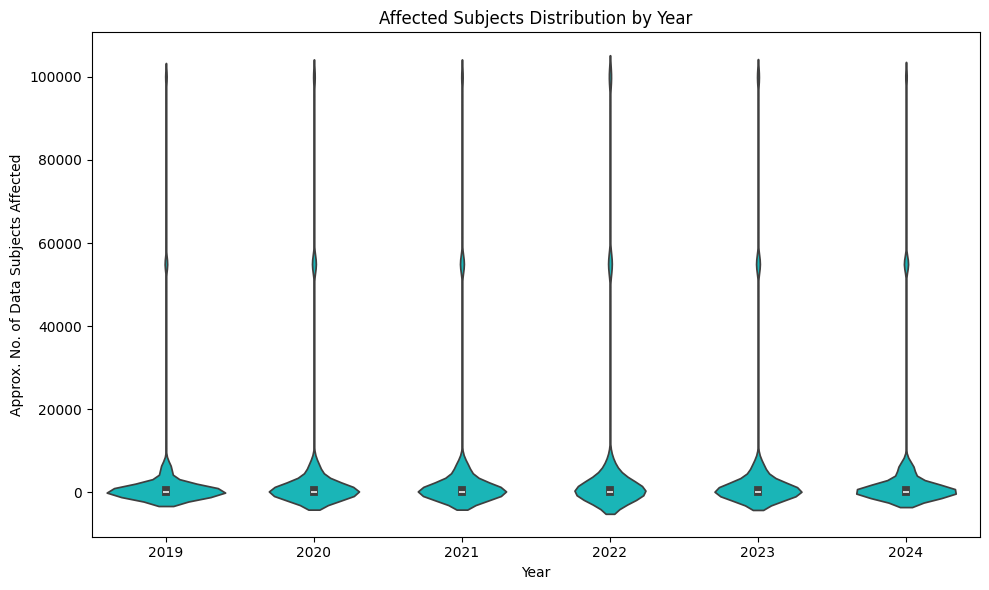

In [38]:
# 5. Violin Plot - Affected Subjects by Year
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Year', y='No. Data Subjects Affected Num',
               color='#00CED1')
plt.title('Affected Subjects Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Approx. No. of Data Subjects Affected')
plt.grid(False)
plt.tight_layout()
plt.show()

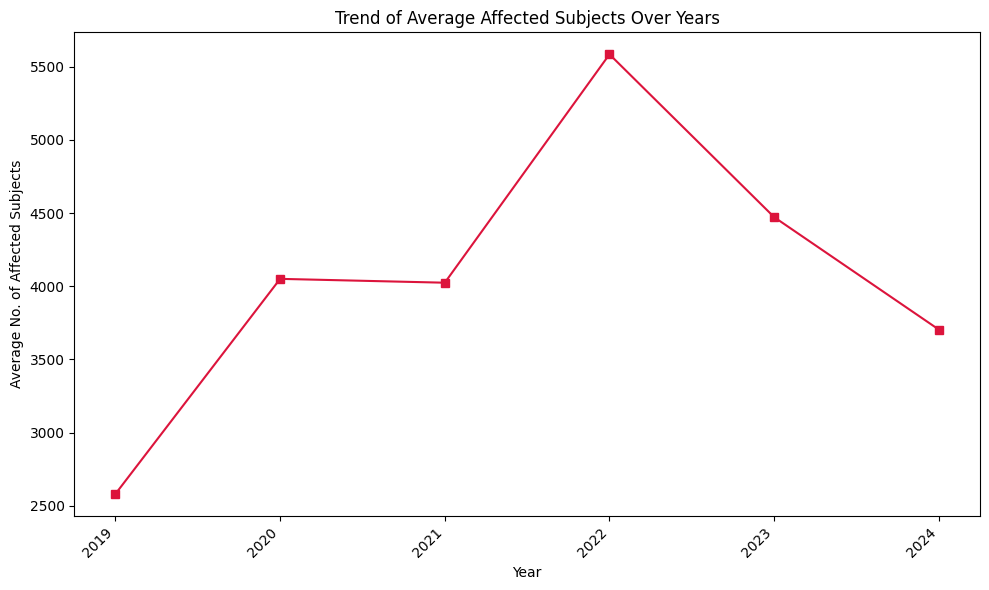

In [46]:
# 8b. Line plot: Yearly trend
yearly_avg = (df
    .dropna(subset=['No. Data Subjects Affected Num'])
    .groupby('Year')['No. Data Subjects Affected Num']
    .mean()
)

plt.figure(figsize=(10,6))
plt.plot(yearly_avg.index.astype(str), yearly_avg.values, color='#DC143C', marker='s')
plt.title('Trend of Average Affected Subjects Over Years')
plt.ylabel('Average No. of Affected Subjects')
plt.xlabel('Year')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.tight_layout()
plt.show()
